In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import cv2

import weyl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
base_image = cv2.imread('../datasets/tests_images/tree.png', cv2.IMREAD_GRAYSCALE) / 255.0
base_image = cv2.resize(base_image, dsize=(128, 128), interpolation=cv2.INTER_CUBIC)

part_image = base_image[54:85, 54:85]

np.random.seed(42)
noised_image = np.random.normal(base_image, 0.2)

Text(0.5, 1.0, 'Noised image')

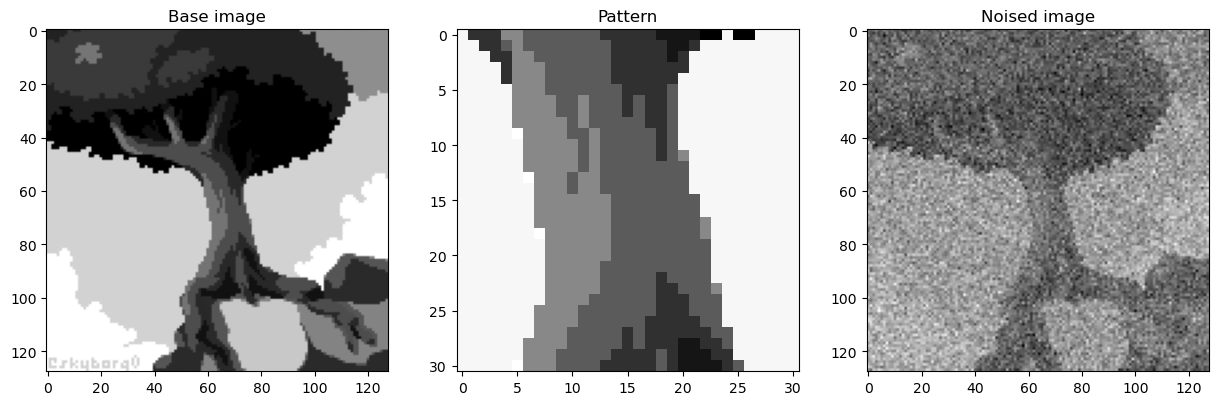

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 15))

ax1.imshow(base_image, cmap='gray')
ax1.set_title("Base image")

ax2.imshow(part_image, cmap='gray')
ax2.set_title("Pattern")

ax3.imshow(noised_image, cmap='gray')
ax3.set_title("Noised image")

100%|██████████| 128/128 [00:53<00:00,  2.40it/s]

------------------------------------------------------------------
Total execution time        : 53.39045429229736 seconds
Average row execution time  : 0.41711292415857315 seconds
Average cell execution time : 0.0032586947199888527 seconds
------------------------------------------------------------------
Found at position : (np.int64(69), np.int64(69))


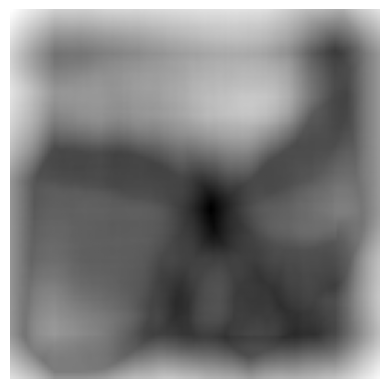

In [11]:
diff_image_optimized, (px, py) = weyl.PatternMatching(part_image, noised_image, weyl.WeylOptimized)
print(f"Found at position : {px, py}")
plt.axis('off')
plt.imshow(diff_image_optimized, cmap='gray')
plt.show()

  0%|          | 0/128 [00:00<?, ?it/s]

100%|██████████| 128/128 [04:28<00:00,  2.10s/it]

------------------------------------------------------------------
Total execution time        : 268.4092094898224 seconds
Average row execution time  : 2.0969469491392374 seconds
Average cell execution time : 0.016382398040150292 seconds
------------------------------------------------------------------


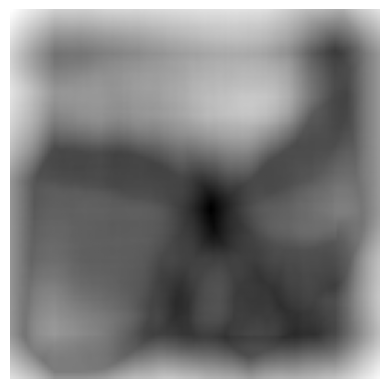

In [12]:
diff_image_naive, _ = weyl.PatternMatching(part_image, noised_image, weyl.WeylNaive)
plt.axis('off')
plt.imshow(diff_image_naive, cmap='gray')
plt.show()

In [13]:
models_variation = diff_image_naive - diff_image_optimized

reconstructed_image = base_image.copy()
reconstructed_image[54:85, 54:85] = 0.0
reconstructed_image[px - 15:px + 15 + 1, py - 15:py + 15 + 1] = part_image

delta_image = base_image - reconstructed_image

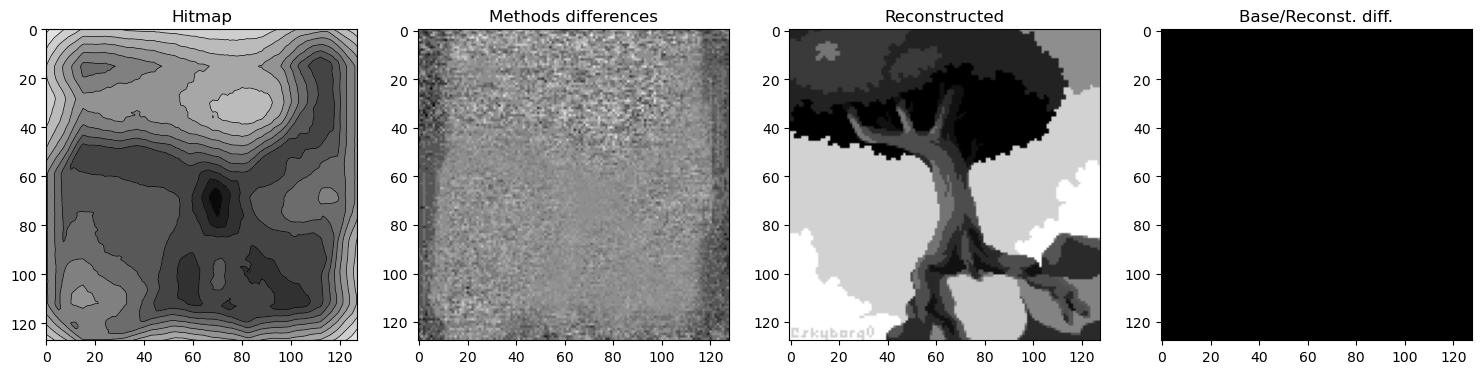

In [14]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 15))

ax1.contourf(diff_image_optimized, levels=12, cmap='gray')
ax1.contour(diff_image_optimized, levels=12, colors='black', linewidths=0.5)
ax1.set_aspect('equal')
ax1.invert_yaxis()
ax1.set_title("Hitmap")

ax2.imshow(models_variation, cmap='gray')
ax2.set_title("Methods differences")

ax3.imshow(reconstructed_image, cmap='gray')
ax3.set_title("Reconstructed")

ax4.imshow(delta_image, cmap='gray')
ax4.set_title("Base/Reconst. diff.")

plt.tight_layout()
plt.show()